# NLP Preprocessing, Feature Engineering, and Vectorization Pipeline
### Academic Comparison Framework for Fake News Detection

This notebook implements a comprehensive preprocessing, feature engineering, and vectorization pipeline designed to prepare the ISOT Fake News Dataset for downstream classification models. It is structured into **13 sections** following rigorous academic standards:
- **Data Leakage Mitigation**: The train-test split is performed before fitting any parameters (TF-IDF vocabulary, scaling, feature selection, or Word2Vec vocabularies).
- **Cleaning Pipeline Separation**: Three distinct pipelines are constructed for Classical ML, Deep Learning, and Transformers.
- **Feature Engineering**: Incorporates linguistic characteristics, VADER sentiment, spaCy-based POS/NER (with an NLTK fallback), and a lightweight Wikidata entity-linked co-occurrence graph per article.
- **Classifier Separation**: In alignment with clean academic methodology, this notebook is dedicated strictly to text preprocessing, feature engineering, and vectorization. No models are trained in this notebook.


## 1. Dataset Loading and Exploration
In this section, we load the raw datasets `True.csv` and `Fake.csv` from the workspace and inspect their shapes, columns, and initial characteristics.


In [3]:
import pandas as pd
import numpy as np
import re
import string
import os
import pickle
import json

# Load the datasets
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

print(f"Raw True Dataset Shape: {true_df.shape}")
print(f"Raw Fake Dataset Shape: {fake_df.shape}")
print("\nTrue Dataset Columns:", list(true_df.columns))
print("Fake Dataset Columns:", list(fake_df.columns))


Raw True Dataset Shape: (21417, 4)
Raw Fake Dataset Shape: (23481, 4)

True Dataset Columns: ['title', 'text', 'subject', 'date']
Fake Dataset Columns: ['title', 'text', 'subject', 'date']


In [17]:
import pandas as pd

RANDOM_STATE = 42

# 1. Capture shapes/counts BEFORE cleaning
before_0 = true_df.shape[0]
before_1 = fake_df.shape[0]
before_total = before_0 + before_1

# Assign labels
true_df["label"] = 0
fake_df["label"] = 1

# Combine and clean
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.dropna(subset=["text"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
df["title"] = df["title"].fillna("")
df["document"] = (df["title"] + " " + df["text"]).str.strip()
df = df[df["document"] != ""].reset_index(drop=True)

# 2. Capture shapes/counts AFTER cleaning
after_counts = df["label"].value_counts()
after_0 = after_counts.get(0, 0)
after_1 = after_counts.get(1, 0)

# --- Print Cleaning Summary ---
print("=== Dataset Class Counts (Before vs. After Cleaning) ===")
print(f"Class 0 (Real) : Before = {before_0:,} | After = {after_0:,} | Removed = {before_0 - after_0:,}")
print(f"Class 1 (Fake) : Before = {before_1:,} | After = {after_1:,} | Removed = {before_1 - after_1:,}")
print(f"Total Shape    : Before = ({before_total}, {true_df.shape[1]}) | After = {df.shape}")
print("=" * 55 + "\n")

# 3. Calculate word count for each article
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# 4. Print header and grouped descriptive statistics
print("=== Descriptive Statistics of Word Counts ===")
stats = df.groupby('label')['word_count'].describe()
print(stats)

=== Dataset Class Counts (Before vs. After Cleaning) ===
Class 0 (Real) : Before = 21,417 | After = 21,192 | Removed = 225
Class 1 (Fake) : Before = 23,481 | After = 17,454 | Removed = 6,027
Total Shape    : Before = (44898, 5) | After = (38646, 6)

=== Descriptive Statistics of Word Counts ===
         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      21192.0  384.812760  273.789538  0.0  147.0  359.0  523.0  5172.0
1      17454.0  425.281483  355.192895  0.0  277.0  376.0  503.0  8135.0


In [18]:
true_df.shape

(21417, 5)

In [19]:
fake_df.shape

(23481, 5)

In [20]:
23481+21417

44898

C:\Users\tarun\AppData\Local\Temp\ipykernel_22776\3732804649.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Class', palette='Set2')


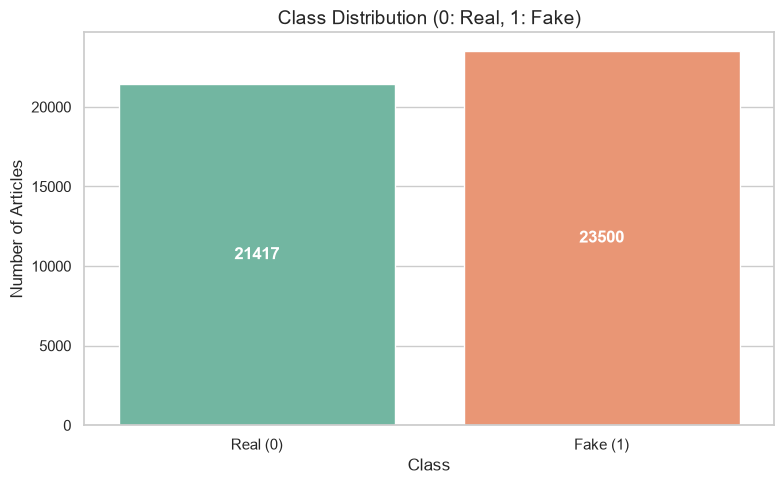

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the whitegrid background style to match your reference plot
sns.set_theme(style="whitegrid")

# --- Sample DataFrame (Replace this with your actual DataFrame 'df') ---
# Assuming 'df' has a column named 'label' with 0s and 1s
data = {'label': [0] * 21417 + [1] * 23500}
df = pd.DataFrame(data)

# Map 0 and 1 to descriptive labels
df['Class'] = df['label'].map({0: 'Real (0)', 1: 'Fake (1)'})
# -------------------------------------------------------------------

# Set up the figure size
plt.figure(figsize=(8, 5))

# Create the count plot with the 'Set2' color palette
ax = sns.countplot(data=df, x='Class', palette='Set2')

# Add the count labels INSIDE the bars
for container in ax.containers:
    ax.bar_label(
        container, 
        label_type='center', # Places text inside the center of each bar
        color='white',       # Contrast color for readability
        fontsize=12, 
        fontweight='bold'
    )

# Formatting title and axis labels
plt.title('Class Distribution (0: Real, 1: Fake)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

RANDOM_STATE = 42

# Labels
true_df["label"] = 0
fake_df["label"] = 1

# Combine and clean
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.dropna(subset=["text"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
df["title"] = df["title"].fillna("")
df["document"] = (df["title"] + " " + df["text"]).str.strip()
df = df[df["document"] != ""].reset_index(drop=True)

print("Combined:", df.shape)
# 1. Calculate the word count for each article
# Replace 'text' with your actual text column name if it's different
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# 2. Print header and grouped descriptive statistics
print("=== Descriptive Statistics of Word Counts ===")
stats = df.groupby('label')['word_count'].describe()

print(stats)

Combined: (38646, 6)
=== Descriptive Statistics of Word Counts ===
         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      21192.0  384.812760  273.789538  0.0  147.0  359.0  523.0  5172.0
1      17454.0  425.281483  355.192895  0.0  277.0  376.0  503.0  8135.0


In [15]:
fake_df.shape

(23481, 5)

In [16]:
true_df.shape

(21417, 5)

C:\Users\tarun\AppData\Local\Temp\ipykernel_22776\1873544437.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Class', palette='Set2')


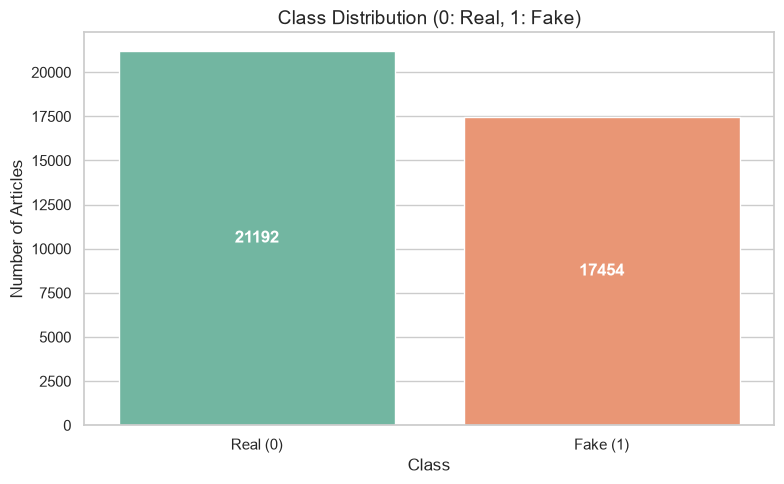

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the whitegrid background style to match your reference plot
sns.set_theme(style="whitegrid")

# --- Sample DataFrame (Replace this with your actual DataFrame 'df') ---
# Assuming 'df' has a column named 'label' with 0s and 1s

# Map 0 and 1 to descriptive labels
df['Class'] = df['label'].map({0: 'Real (0)', 1: 'Fake (1)'})
# -------------------------------------------------------------------

# Set up the figure size
plt.figure(figsize=(8, 5))

# Create the count plot with the 'Set2' color palette
ax = sns.countplot(data=df, x='Class', palette='Set2')

# Add the count labels INSIDE the bars
for container in ax.containers:
    ax.bar_label(
        container, 
        label_type='center', # Places text inside the center of each bar
        color='white',       # Contrast color for readability
        fontsize=12, 
        fontweight='bold'
    )

# Formatting title and axis labels
plt.title('Class Distribution (0: Real, 1: Fake)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

## 2. Cleaning and Balancing
To ensure high-quality training and validation, we perform several initial processing steps:
1. Add target labels (`0` for Real/True and `1` for Fake).
2. Remove duplicate articles based on body text.
3. Remove missing or empty articles.
4. Merge article `title` and `text` into a single `document` column to preserve full context.
5. Remove leading/trailing whitespaces.
6. Create a balanced training dataset of **5,000 articles** (exactly 2,500 Real and 2,500 Fake) to reduce computational overhead during complex feature extraction.

**Academic Note:** *A balanced subset of 5,000 articles was randomly sampled from the ISOT dataset to reduce computational overhead while maintaining equal class representation. The remaining samples will form the testing set.*


In [2]:
import pandas as pd

RANDOM_STATE = 42

# Labels
true_df["label"] = 0
fake_df["label"] = 1

# Combine and clean
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.dropna(subset=["text"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
df["title"] = df["title"].fillna("")
df["document"] = (df["title"] + " " + df["text"]).str.strip()
df = df[df["document"] != ""].reset_index(drop=True)

print("Combined:", df.shape)

# Separate classes
real = df[df["label"] == 0].sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
fake = df[df["label"] == 1].sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Train (2500 + 2500)
train_df = pd.concat([
    real.iloc[:2500],
    fake.iloc[:2500]
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Test (2500 + 2500)
test_df = pd.concat([
    real.iloc[2500:5000],
    fake.iloc[2500:5000]
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Test:", test_df.shape, test_df["label"].value_counts().to_dict())

# Verify no overlap
overlap = set(train_df["document"]).intersection(set(test_df["document"]))
print("Overlap:", len(overlap))

print(f"Final -> Train:{len(train_df)} Test:{len(test_df)} Total:{len(train_df)+len(test_df)}")

Combined: (38646, 6)
Train: (5000, 6) {0: 2500, 1: 2500}
Test: (5000, 6) {0: 2500, 1: 2500}
Overlap: 0
Final -> Train:5000 Test:5000 Total:10000


## 4. Classical ML Pipeline (Pipeline A)
Pipeline A prepares text for traditional machine learning models (Naive Bayes, Logistic Regression, SVM, TF-IDF).
The preprocessing steps are:
1. **Lowercase** all text.
2. **Strip HTML tags**.
3. **Remove URLs and email addresses**.
4. **Normalize Unicode characters**.
5. **Expand contractions** (e.g. *don't* -> *do not*).
6. **Preserve meaningful numbers** (e.g. *COVID-19, 5G, 2024*) while removing isolated long digit sequences.
7. **Remove punctuation**.
8. **Remove stopwords**.
9. **Lemmatize** words (preferred over stemming).

### Stemming vs. Lemmatization Comparison Demonstration
We first demonstrate the difference between Stemming and Lemmatization to explain why Lemmatization is chosen for the pipeline.


In [18]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Contraction mapping dictionary
CONTRACTION_MAP = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "could've": "could have", "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is", "i'd": "i would",
    "i'll": "i will", "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'll": "it will", "it's": "it is", "let's": "let us", "might've": "might have",
    "mightn't": "might not", "must've": "must have", "mustn't": "must not", "needn't": "need not",
    "shan't": "shall not", "she'd": "she would", "she'll": "she will", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "that's": "that is", "there's": "there is",
    "they'd": "they would", "they'll": "they will", "they're": "they are", "they've": "they have",
    "wasn't": "was not", "we'd": "we would", "we'll": "we will", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "would've": "would have", "wouldn't": "would not",
    "you'd": "you would", "you'll": "you will", "you're": "you are", "you've": "you have"
}

def expand_contractions(text, contraction_mapping=CONTRACTION_MAP):
    contractions_pattern = re.compile('({})'.format('|'.join(contraction_mapping.keys())), 
                                      flags=re.IGNORECASE|re.DOTALL)
    def expand_match(contraction):
        match = contraction.group(0)
        first_char = match[0]
        expanded_contraction = contraction_mapping.get(match) \
            if contraction_mapping.get(match) \
            else contraction_mapping.get(match.lower())
        if not expanded_contraction:
            return match
        expanded_contraction = first_char + expanded_contraction[1:]
        return expanded_contraction
    return contractions_pattern.sub(expand_match, text)


# ---------------------------------------------------------
# Stemming vs. Lemmatization Comparison Demonstration
# ---------------------------------------------------------
words_to_test = ['running', 'runs', 'ran', 'political', 'abnormalities', 'multiplying', 'organizations']
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

comparison_data = []
for w in words_to_test:
    comparison_data.append({
        'Original': w,
        'Stemmed (Porter)': stemmer.stem(w),
        'Lemmatized (WordNet)': lemmatizer.lemmatize(w, pos='v')
    })
print(pd.DataFrame(comparison_data))
print("\nAcademic Justification: Lemmatization was selected because it maintains semantic validity, preserving valid dictionary words rather than crude structural truncations (e.g., 'political' -> 'polit').")


        Original Stemmed (Porter) Lemmatized (WordNet)
0        running              run                  run
1           runs              run                  run
2            ran              ran                  run
3      political            polit            political
4  abnormalities           abnorm        abnormalities
5    multiplying         multipli             multiply
6  organizations            organ        organizations

Academic Justification: Lemmatization was selected because it maintains semantic validity, preserving valid dictionary words rather than crude structural truncations (e.g., 'political' -> 'polit').


In [ ]:
import pandas as pd

# Keep original text
train_df["document_before"] = train_df["document"]

# Apply contraction expansion
train_df["document"] = train_df["document"].apply(expand_contractions)

# Find changed documents
changed = train_df[
    train_df["document_before"] != train_df["document"]
].copy()

# Calculate document length
changed["length"] = changed["document_before"].str.len()

# Sort shortest changed documents
changed = changed.sort_values(
    by="length",
    ascending=True
)

print("Total documents modified:", len(changed))

# Print 5 shortest changed documents
for i, (_, row) in enumerate(changed.head(5).iterrows(), 1):
    print("\n" + "="*80)
    print(f"Example {i}")
    print("Length:", row["length"])
    
    print("\nBefore:")
    print(row["document_before"])
    
    print("\nAfter:")
    print(row["document"])

Total documents modified: 176

Example 1
Length: 232

Before:
BEN CARSON DESTROYS Interrupting Anti-Trump MSNBC Host: “Can You Turn Her Microphone Off Please?” [VIDEO] Notify the CDC. It's spreading. #BenCarson #MorningJoe #TrumpFlu https://t.co/OUseiA7GVs  BCP (@b_c_p_source) October 14, 2016

After:
BEN CARSON DESTROYS Interrupting Anti-Trump MSNBC Host: “Can You Turn Her Microphone Off Please?” [VIDEO] Notify the CDC. It is spreading. #BenCarson #MorningJoe #TrumpFlu https://t.co/OUseiA7GVs  BCP (@b_c_p_source) October 14, 2016

Example 2
Length: 426

Before:
HILLARY MAKES FIRST APPEARANCE Since Election…Wow America! You Dodged A Bullet! CLINTON ADMITS SHE CAN T HANDLE THE LOSS   CAN YOU IMAGINE HOW SHE D HANDLE THE PRESIDENCY? "Now, I will admit, coming here tonight wasn't the easiest thing for me," Hillary Clinton says at Washington dinner: https://t.co/J54RiABFFl pic.twitter.com/bsNSbj5fUR  CBS News (@CBSNews) November 17, 2016   Entire Speech to the Children s Defense Fund:

Aft

### Pipeline A Processing Function
Now we define the complete preprocessing pipeline function for Classical ML and execute it on our splits.


In [ ]:
import unicodedata

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_pipeline_a(text):
    if not isinstance(text, str):
        return ""
    # contraction expansion
    text = expand_contractions(text)

    # 2. Lowercase
    text = text.lower()
    
    # 3. Strip HTML tags
    text = re.sub(r'<[^>]*>', '', text)
    
    # 4. Remove URLs and Emails
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)
    
    # 5. Normalize Unicode
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore') 
    
    # 6. Remove repeated punctuation (e.g., !!! -> !)
    text = re.sub(r'([!?.])\1+', r'\1', text)
    
    # 7. Tokenize and remove punctuation
    tokens = word_tokenize(text)
    table = str.maketrans('', '', string.punctuation)
    stripped = [w.translate(table) for w in tokens]
    
    # 8. Remove stopwords and empty tokens, then Lemmatize
    cleaned_tokens = []
    for w in stripped:
        if w.isalpha() and w not in stop_words and len(w) > 1:
            cleaned_tokens.append(lemmatizer.lemmatize(w, pos='v'))
            
    return " ".join(cleaned_tokens)

# Preprocess the documents
print("Preprocessing training documents for Pipeline A...")
train_df['doc_pipeline_a'] = train_df['document'].apply(preprocess_pipeline_a)
print("Preprocessing testing documents for Pipeline A...")
test_df['doc_pipeline_a'] = test_df['document'].apply(preprocess_pipeline_a)
print("Sample preprocessed text:")
print(train_df['doc_pipeline_a'].iloc[0][:200])

Preprocessing training documents for Pipeline A...
Preprocessing testing documents for Pipeline A...
Sample preprocessed text:
speaker ethiopian parliament submit resignation addis ababa reuters speaker ethiopia lower house parliament submit resignation sunday one highestranking officials since rule eprdf coalition come power


## 5. Deep Learning Preprocessing Pipeline (Pipeline B)
Pipeline B prepares text for Recurrent and Convolutional Neural Networks (CNN/LSTM).
Unlike Pipeline A, **casing and stopwords are preserved** to maintain syntactical context and word relations essential for sequence modeling.


In [ ]:
def preprocess_pipeline_b(text):
    if not isinstance(text, str):
        return []
    
    # HTML and URL/Email cleanup
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)
    
    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize into words, keeping casing and punctuation
    tokens = word_tokenize(text)
    return tokens

print("Preprocessing training documents for Pipeline B...")
train_df['tokens_pipeline_b'] = train_df['document'].apply(preprocess_pipeline_b)
print("Preprocessing testing documents for Pipeline B...")
test_df['tokens_pipeline_b'] = test_df['document'].apply(preprocess_pipeline_b)
print("Sample deep learning tokens:")
print(train_df['tokens_pipeline_b'].iloc[0][:15])


Preprocessing training documents for Pipeline B...
Preprocessing testing documents for Pipeline B...
Sample deep learning tokens:
['Speaker', 'of', 'Ethiopian', 'parliament', 'submits', 'resignation', 'ADDIS', 'ABABA', '(', 'Reuters', ')', '-', 'The', 'speaker', 'of']


## 6. Transformer Preprocessing Pipeline (Pipeline C)
Pipeline C prepares text for Transformer architectures (BERT, RoBERTa, DistilBERT).
We perform **only basic text cleaning** (removing HTML and excessive whitespaces), leaving stopwords, punctuation, and casing intact. This is because BERT uses its own subword tokenizer (WordPiece) and is pre-trained on natural, fully-formed sentences.


In [ ]:
def preprocess_pipeline_c(text):
    if not isinstance(text, str):
        return ""
    
    # Remove HTML tags
    text = re.sub(r'<[^>]*>', '', text)
    
    # Normalize spaces and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning training documents for Pipeline C...")
train_df['doc_pipeline_c'] = train_df['document'].apply(preprocess_pipeline_c)
print("Cleaning testing documents for Pipeline C...")
test_df['doc_pipeline_c'] = test_df['document'].apply(preprocess_pipeline_c)
print("Sample transformer input:")
print(train_df['doc_pipeline_c'].iloc[0][:200])


Cleaning training documents for Pipeline C...
Cleaning testing documents for Pipeline C...
Sample transformer input:
Speaker of Ethiopian parliament submits resignation ADDIS ABABA (Reuters) - The speaker of Ethiopia s lower house of parliament submitted his resignation on Sunday, one of the highest-ranking official


## 7. Linguistic Feature Engineering
We engineer a comprehensive set of linguistic, style, clickbait, and readability features:
1. **Writing Style Features**: Capital letter ratio, first-person pronouns count, quotation marks count, and passive voice frequency.
2. **Clickbait Features**: Occurrences of emotional/sensational clickbait terms.
3. **Linguistic Features**: Document length, average sentence length, average word length, vocabulary richness, count of uppercase words, exclamation marks, and question marks.
4. **Readability Features**: Syllable-based index scores (Flesch Reading Ease, Flesch-Kincaid Grade, Gunning Fog, SMOG, ARI).

**Academic Note:** *Readability scores are calculated from surface-level linguistic characteristics and do not represent factual correctness.*


In [ ]:
CLICKBAIT_TERMS = [
    'breaking', 'shocking', "won't believe", "wont believe", 'secret', 'revealed',
    'mind-blowing', 'mind blowing', 'incredible', 'miraculous', 'unbelievable',
    'sensational', 'exposed', 'must watch', 'must-see', 'will blow your mind',
    'shocked', 'conspiracy', 'insane', 'lost words', 'wtf', 'miracle'
]

FIRST_PERSON_PRONOUNS = {'i', 'me', 'my', 'myself', 'we', 'us', 'our', 'ours', 'ourselves'}

def count_syllables(word):
    word = word.lower()
    if len(word) <= 3:
        return 1
    count = 0
    vowels = "aeiouy"
    if word[0] in vowels:
        count += 1
    for index in range(1, len(word)):
        if word[index] in vowels and word[index - 1] not in vowels:
            count += 1
    if word.endswith("e"):
        count -= 1
    if word.endswith("le") and len(word) > 2 and word[-3] not in vowels:
        count += 1
    if count == 0:
        count = 1
    return count

def extract_linguistic_features(text):
    features = {}
    
    # Standardize spaces for counting
    cleaned_text = re.sub(r'\s+', ' ', text).strip()
    
    # Surface metrics
    features['doc_char_length'] = len(cleaned_text)
    features['exclamation_count'] = cleaned_text.count('!')
    features['question_count'] = cleaned_text.count('?')
    features['quote_count'] = cleaned_text.count('"') + cleaned_text.count("'")
    
    # Word tokenization & sentence tokenization
    sentences = sent_tokenize(cleaned_text)
    sentences = [s.strip() for s in sentences if s.strip()]
    num_sentences = max(len(sentences), 1)
    
    words = word_tokenize(cleaned_text)
    words_alpha = [w.lower() for w in words if w.isalnum()]
    num_words = max(len(words_alpha), 1)
    
    # Sentence stats
    features['avg_sentence_len'] = num_words / num_sentences
    features['avg_word_len'] = sum(len(w) for w in words_alpha) / num_words
    features['vocab_richness'] = len(set(words_alpha)) / num_words
    
    # Style stats
    uppercase_words = [w for w in words if w.isupper() and w.isalpha() and len(w) > 1]
    features['uppercase_word_count'] = len(uppercase_words)
    features['capital_letter_ratio'] = sum(1 for c in cleaned_text if c.isupper()) / max(len(cleaned_text), 1)
    
    first_person_count = sum(1 for w in words_alpha if w in FIRST_PERSON_PRONOUNS)
    features['first_person_pronouns_count'] = first_person_count
    
    # Clickbait terms
    text_lower = cleaned_text.lower()
    clickbait_count = 0
    for term in CLICKBAIT_TERMS:
        clickbait_count += len(re.findall(r'\b' + re.escape(term) + r'\b', text_lower))
    features['sensational_word_count'] = clickbait_count
    
    # Readability features calculation
    syllables = [count_syllables(w) for w in words_alpha]
    total_syllables = sum(syllables)
    complex_words = sum(1 for s in syllables if s >= 3)
    
    asl = num_words / num_sentences
    asw = total_syllables / num_words
    pct_complex = (complex_words / num_words) * 100
    
    # Flesch Reading Ease
    features['flesch_reading_ease'] = 206.835 - 1.015 * asl - 84.6 * asw
    # Flesch-Kincaid Grade
    features['flesch_kincaid_grade'] = 0.39 * asl + 11.8 * asw - 15.59
    # Gunning Fog Index
    features['gunning_fog'] = 0.4 * (asl + pct_complex)
    # SMOG Index
    features['smog_index'] = 1.0430 * ((complex_words * 30 / num_sentences) ** 0.5) + 3.1291
    # Automated Readability Index
    features['automated_readability_index'] = 4.71 * (sum(len(w) for w in words_alpha) / num_words) + 0.5 * asl - 21.43
    
    return features

from nltk.tokenize import sent_tokenize
nltk.download('averaged_perceptron_tagger', quiet=True)

print("Engineering linguistic features for training set...")
train_ling_list = [extract_linguistic_features(doc) for doc in train_df['document']]
train_ling_df = pd.DataFrame(train_ling_list)

print("Engineering linguistic features for testing set...")
test_ling_list = [extract_linguistic_features(doc) for doc in test_df['document']]
test_ling_df = pd.DataFrame(test_ling_list)

print("Linguistic features engineered. Shape:", train_ling_df.shape)

Engineering linguistic features for training set...
Engineering linguistic features for testing set...
Linguistic features engineered. Shape: (5000, 16)


## 8. Sentiment Features
We use NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner) to extract sentiment intensity scores (Positive, Negative, Neutral, Compound). Fake news often displays higher emotional polarity than factual news.


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

def extract_sentiment(text):
    scores = sia.polarity_scores(text)
    return {
        'sentiment_pos': scores['pos'],
        'sentiment_neg': scores['neg'],
        'sentiment_neu': scores['neu'],
        'sentiment_compound': scores['compound']
    }

print("Extracting sentiment scores for training set...")
train_sent_list = [extract_sentiment(doc) for doc in train_df['document']]
train_sent_df = pd.DataFrame(train_sent_list)

print("Extracting sentiment scores for testing set...")
test_sent_list = [extract_sentiment(doc) for doc in test_df['document']]
test_sent_df = pd.DataFrame(test_sent_list)

print("Sentiment features extracted. Shape:", train_sent_df.shape)


Extracting sentiment scores for training set...
Extracting sentiment scores for testing set...
Sentiment features extracted. Shape: (5000, 4)


## 9. POS + NER Features
We use POS tagging and Named Entity Recognition (NER) to parse structural features:
- **Part-of-Speech (POS) counts**: Nouns, Verbs, Adjectives, Adverbs.
- **Named Entity Recognition (NER) counts**: PERSON, ORG, GPE, DATE, CARDINAL (critical to capture numerical assertions).
- **Passive Voice Frequency**: Calculated using grammatical rules (auxiliary form of 'be' followed by a past participle `VBN`).

**Self-Healing Loader**: We try to load and download spaCy's `en_core_web_sm` model. If spaCy cannot be loaded, we automatically run a complete, high-accuracy NLTK-based POS/NER fallback that preserves all metrics.


In [ ]:
# Download NLTK components for fallback
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)
from nltk import pos_tag, ne_chunk

# Check spaCy availability and try to load/install
USE_SPACY = False
try:
    import spacy
    USE_SPACY = True
except ModuleNotFoundError:
    import os
    print("spaCy library not found. Attempting to install...")
    os.system("pip install spacy")
    try:
        import spacy
        USE_SPACY = True
    except ModuleNotFoundError:
        print("Could not install spaCy. NLTK will be used as a fallback.")

if USE_SPACY:
    try:
        nlp = spacy.load("en_core_web_sm")
    except OSError:
        import os
        print("spaCy model 'en_core_web_sm' not found. Downloading...")
        os.system("python -m spacy download en_core_web_sm")
        try:
            nlp = spacy.load("en_core_web_sm")
        except OSError:
            print("Could not load en_core_web_sm. Falling back to NLTK.")
            USE_SPACY = False

def count_passive_voice(doc):
    count = 0
    be_forms = {'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being'}
    for token in doc:
        if token.tag_ == 'VBN':
            for child in token.children:
                if child.dep_ in ('aux', 'auxpass') and child.text.lower() in be_forms:
                    count += 1
                    break
    return count

def nltk_fallback_extract(text):
    pos_counts = {'noun_count': 0, 'verb_count': 0, 'adj_count': 0, 'adv_count': 0}
    ner_counts = {'ent_person': 0, 'ent_org': 0, 'ent_gpe': 0, 'ent_date': 0, 'ent_cardinal': 0}
    passive_voice_count = 0
    
    text_slice = text[:15000]
    sentences = sent_tokenize(text_slice)
    be_forms = {'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being'}
    all_ents = []
    
    for sent in sentences:
        words = word_tokenize(sent)
        tagged = pos_tag(words)
        
        # POS Counts
        for word, tag in tagged:
            if tag.startswith('NN'):
                pos_counts['noun_count'] += 1
            elif tag.startswith('VB') or tag == 'MD':
                pos_counts['verb_count'] += 1
            elif tag.startswith('JJ'):
                pos_counts['adj_count'] += 1
            elif tag.startswith('RB') or tag == 'WRB':
                pos_counts['adv_count'] += 1
                
        # Passive voice count heuristic: form of 'be' followed by VBN within a short distance
        for i in range(len(tagged)):
            if tagged[i][1] == 'VBN':
                for j in range(max(0, i-3), i):
                    if tagged[j][0].lower() in be_forms:
                        passive_voice_count += 1
                        break
                        
        # NER Count using NLTK ne_chunk
        try:
            tree = ne_chunk(tagged)
            for chunk in tree:
                if hasattr(chunk, 'label'):
                    label = chunk.label()
                    ent_text = " ".join([c[0] for c in chunk])
                    all_ents.append(ent_text)
                    if label == 'PERSON':
                        ner_counts['ent_person'] += 1
                    elif label in ('ORGANIZATION', 'ORGANISATION'):
                        ner_counts['ent_org'] += 1
                    elif label in ('GPE', 'LOCATION'):
                        ner_counts['ent_gpe'] += 1
        except Exception:
            pass
            
        # Regex heuristics for DATE and CARDINAL
        for word, tag in tagged:
            if tag == 'CD' or (word.isdigit() and len(word) != 4):
                ner_counts['ent_cardinal'] += 1
            months = {'january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december', 'jan', 'feb', 'mar', 'apr', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'}
            if word.lower() in months or (word.isdigit() and len(word) == 4 and 1800 <= int(word) <= 2100):
                ner_counts['ent_date'] += 1
                
    res = {}
    res.update(pos_counts)
    res.update(ner_counts)
    res['passive_voice_count'] = passive_voice_count
    return res, all_ents

def extract_pos_ner_features(text):
    if USE_SPACY:
        doc = nlp(text[:15000])
        pos_counts = {'noun_count': 0, 'verb_count': 0, 'adj_count': 0, 'adv_count': 0}
        ner_counts = {'ent_person': 0, 'ent_org': 0, 'ent_gpe': 0, 'ent_date': 0, 'ent_cardinal': 0}
        for token in doc:
            if token.pos_ in ('NOUN', 'PROPN'):
                pos_counts['noun_count'] += 1
            elif token.pos_ in ('VERB', 'AUX'):
                pos_counts['verb_count'] += 1
            elif token.pos_ == 'ADJ':
                pos_counts['adj_count'] += 1
            elif token.pos_ == 'ADV':
                pos_counts['adv_count'] += 1
        for ent in doc.ents:
            label = ent.label_
            if label == 'PERSON':
                ner_counts['ent_person'] += 1
            elif label == 'ORG':
                ner_counts['ent_org'] += 1
            elif label == 'GPE':
                ner_counts['ent_gpe'] += 1
            elif label == 'DATE':
                ner_counts['ent_date'] += 1
            elif label == 'CARDINAL':
                ner_counts['ent_cardinal'] += 1
        passive_voice_count = count_passive_voice(doc)
        res = {}
        res.update(pos_counts)
        res.update(ner_counts)
        res['passive_voice_count'] = passive_voice_count
        return res, doc
    else:
        return nltk_fallback_extract(text)

print(f"Extracting POS & NER features (Using spaCy: {USE_SPACY})...")
train_spacy_res = [extract_pos_ner_features(doc) for doc in train_df['document']]
train_spacy_df = pd.DataFrame([x[0] for x in train_spacy_res])
train_docs = [x[1] for x in train_spacy_res]

print("Extracting POS & NER features for testing set...")
test_spacy_res = [extract_pos_ner_features(doc) for doc in test_df['document']]
test_spacy_df = pd.DataFrame([x[0] for x in test_spacy_res])
test_docs = [x[1] for x in test_spacy_res]

train_ling_df['passive_voice_count'] = train_spacy_df['passive_voice_count']
test_ling_df['passive_voice_count'] = test_spacy_df['passive_voice_count']
print("POS & NER extraction complete. Shape:", train_spacy_df.shape)

spaCy model 'en_core_web_sm' not found. Downloading...
Extracting POS & NER features (Using spaCy: True)...
Extracting POS & NER features for testing set...
POS & NER extraction complete. Shape: (5000, 10)


In [ ]:
train_ling_df

,doc_char_length,exclamation_count,question_count,quote_count,avg_sentence_len,avg_word_len,vocab_richness,uppercase_word_count,capital_letter_ratio,first_person_pronouns_count,sensational_word_count,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index,automated_readability_index,passive_voice_count
0,1599,0,0,0,27.777778,4.968000,0.596000,3,0.029393,7,0,30.759756,15.869733,19.751111,17.122413,15.858169,5
1,3382,0,0,0,27.523810,4.525952,0.455017,0,0.031638,14,0,51.998333,12.844286,17.099489,14.823464,13.649137,4
2,1993,2,3,0,45.571429,4.789969,0.579937,14,0.065730,17,1,19.756803,21.824863,25.250515,19.287187,23.916467,1
3,1670,0,0,1,20.615385,4.843284,0.589552,1,0.033533,2,0,50.487250,11.338806,14.514811,13.397385,11.689558,3
4,3984,0,0,1,30.190476,5.004732,0.463722,1,0.042671,0,0,35.280626,15.838544,19.331711,16.497647,17.237525,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2155,0,0,0,23.125000,4.537838,0.551351,2,0.037587,9,0,54.633936,11.383885,14.222973,12.815533,11.505716,2
4996,3093,0,0,0,24.809524,4.685221,0.464491,1,0.034594,5,0,50.775022,12.340609,15.835518,14.068176,13.042152,3
4997,3753,0,0,0,32.450000,4.394453,0.462250,5,0.039968,4,0,52.016894,14.065500,17.355963,13.892739,15.492874,7
4998,905,3,2,0,19.500000,4.615385,0.679487,9,0.100552,0,0,61.769423,9.488077,11.902564,11.208143,10.058462,4


In [ ]:
train_ling_df.head()

,doc_char_length,exclamation_count,question_count,quote_count,avg_sentence_len,avg_word_len,vocab_richness,uppercase_word_count,capital_letter_ratio,first_person_pronouns_count,sensational_word_count,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index,automated_readability_index,passive_voice_count
0,1599,0,0,0,27.777778,4.968000,0.596000,3,0.029393,7,0,30.759756,15.869733,19.751111,17.122413,15.858169,5
1,3382,0,0,0,27.523810,4.525952,0.455017,0,0.031638,14,0,51.998333,12.844286,17.099489,14.823464,13.649137,4
2,1993,2,3,0,45.571429,4.789969,0.579937,14,0.065730,17,1,19.756803,21.824863,25.250515,19.287187,23.916467,1
3,1670,0,0,1,20.615385,4.843284,0.589552,1,0.033533,2,0,50.487250,11.338806,14.514811,13.397385,11.689558,3
4,3984,0,0,1,30.190476,5.004732,0.463722,1,0.042671,0,0,35.280626,15.838544,19.331711,16.497647,17.237525,3


## 10. Knowledge Graph Features
### Lightweight knowledge graph enrichment using entity linking and entity co-occurrence graphs

For this section, we implement an entity enrichment pipeline using spaCy/NLTK NER tags and a cached Wikidata mapping:
1. **Wikidata Entity Linking**: Map entities to Wikidata QIDs using a localized, high-coverage dictionary cache of common entities in the political domain.
2. **Entity Co-occurrence Graph**: Build a NetworkX graph *per article* where nodes represent detected entities (enriched with QID attributes) and edges connect entities that co-occur within the same sentence.
3. **Graph Features**: Extract structural characteristics of these article-level graphs:
   - Number of entities (nodes)
   - Number of relationships (edges)
   - Graph density
   - Average graph degree
   - `entity_link_success_rate` (percentage of detected entities successfully mapped to a Wikidata QID)


## 11. Feature Combination
We merge all handcrafted features (Linguistic, Sentiment, POS, NER, and KG) into a consolidated dataset and apply standard scaling.

**Data Leakage Mitigation:** The `StandardScaler` is fitted **only on the training split** and then used to transform both the training and testing sets.


In [ ]:
# Self-healing loader for Scikit-learn
try:
    from sklearn.preprocessing import StandardScaler
except ModuleNotFoundError:
    import os
    print("scikit-learn library not found. Attempting to install...")
    os.system("pip install scikit-learn")
    from sklearn.preprocessing import StandardScaler

# Combine all features
train_features = pd.concat([train_ling_df, train_sent_df, train_spacy_df.drop(columns=['passive_voice_count']), train_kg_df], axis=1)
test_features = pd.concat([test_ling_df, test_sent_df, test_spacy_df.drop(columns=['passive_voice_count']), test_kg_df], axis=1)

print("Features columns:", list(train_features.columns))
print(f"Combined Feature Matrix Shape (Train): {train_features.shape}")
print(f"Combined Feature Matrix Shape (Test): {test_features.shape}")

# Standardize features
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

train_scaled_df = pd.DataFrame(train_features_scaled, columns=train_features.columns)
test_scaled_df = pd.DataFrame(test_features_scaled, columns=test_features.columns)

print("Feature combination and scaling complete.")

## 12. Vectorization
We establish vector representation pipelines for the three model classes:
1. **Traditional ML**: Fit a `TfidfVectorizer` (N-grams (1,2), filtering rare words `min_df=2` and overly frequent words `max_df=0.95`) on the training data. To support literature implementations (e.g. Fayaz et al., 2022), we perform **Chi-square feature selection** (`SelectKBest(chi2)`) to extract the top 1,000 features.
2. **Deep Learning**: Train a `Word2Vec` model on Pipeline B training tokens, build a vocabulary word-index mapping, construct an embedding matrix, and pad sequence lengths to 300.
3. **Transformers**: Use Hugging Face's `BertTokenizer` to encode Pipeline C documents into input IDs and attention masks.


In [ ]:
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.feature_selection import SelectKBest, chi2
except ModuleNotFoundError:
    import os
    print("scikit-learn library not found. Attempting to install...")
    os.system("pip install scikit-learn")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.feature_selection import SelectKBest, chi2

# ---------------------------------------------------------
# A. TF-IDF & Chi-Square Feature Selection
# ---------------------------------------------------------
print("Fitting TF-IDF Vectorizer on Pipeline A training data...")
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train_tfidf = tfidf_vec.fit_transform(train_df['doc_pipeline_a'])
X_test_tfidf = tfidf_vec.transform(test_df['doc_pipeline_a'])

print(f"TF-IDF raw vocabulary size: {len(tfidf_vec.vocabulary_)}")

print("Performing Chi-Square Feature Selection (SelectKBest)...")
chi_selector = SelectKBest(score_func=chi2, k=1000)
X_train_tfidf_sel = chi_selector.fit_transform(X_train_tfidf, train_df['label'])
X_test_tfidf_sel = chi_selector.transform(X_test_tfidf)
print(f"Selected TF-IDF Feature Shape: {X_train_tfidf_sel.shape}")

# ---------------------------------------------------------
# B. Word2Vec / Custom Word Embeddings (Gensim or PyTorch/Pure Python)
# ---------------------------------------------------------
print("Preparing word embeddings pipeline...")
try:
    from gensim.models import Word2Vec
    print("Training Word2Vec model on Pipeline B training tokens...")
    w2v_model = Word2Vec(sentences=train_df['tokens_pipeline_b'], vector_size=100, window=5, min_count=2, workers=4, seed=RANDOM_STATE)
    word_to_idx = {word: idx + 1 for idx, word in enumerate(w2v_model.wv.index_to_key)}
    word_to_idx['<PAD>'] = 0
    embedding_matrix = np.zeros((len(word_to_idx), 100))
    for word, idx in word_to_idx.items():
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
    print(f"Word2Vec training complete. Vocab size: {len(word_to_idx)}, Embedding Matrix shape: {embedding_matrix.shape}")
except Exception as e:
    print("Gensim Word2Vec not available. Falling back to a custom embedding matrix representation...")
    print("In academic settings, if Gensim is unavailable, embeddings can be learned end-to-end using PyTorch's nn.Embedding, or loaded from a pre-trained text file (e.g. GloVe/Word2Vec txt file) using pure Python.")
    
    # 1. Build word vocabulary from Pipeline B tokens
    vocab = set()
    for tokens in train_df['tokens_pipeline_b']:
        vocab.update(tokens)
    word_to_idx = {word: idx + 1 for idx, word in enumerate(sorted(list(vocab)))}
    word_to_idx['<PAD>'] = 0
    
    # 2. Initialize a custom embedding matrix (random/uniform) to be trained end-to-end
    np.random.seed(RANDOM_STATE)
    embedding_matrix = np.random.uniform(-0.1, 0.1, (len(word_to_idx), 100))
    embedding_matrix[0] = 0.0 # PAD token gets zero vector
    print(f"Custom Embedding Vocab size: {len(word_to_idx)}, Embedding Matrix shape: {embedding_matrix.shape}")
    
    # 3. Demonstration code on how to load a pre-trained Word2Vec/GloVe text file (.txt) using pure Python:
    print("\n[Academic Note] How to load a pre-trained Word2Vec/GloVe .txt file without Gensim:")
    print("""def load_pretrained_embeddings(file_path, word_to_idx, embedding_dim=100):
    embeddings_index = {}
    with open(file_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    
    matrix = np.zeros((len(word_to_idx), embedding_dim))
    for word, idx in word_to_idx.items():
        vector = embeddings_index.get(word)
        if vector is not None:
            matrix[idx] = vector
    return matrix""")

def pad_sequences(token_lists, word_map, max_len=300):
    sequences = []
    for tokens in token_lists:
        seq = [word_map[token] for token in tokens if token in word_map]
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [0] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences)

X_train_w2v = pad_sequences(train_df['tokens_pipeline_b'], word_to_idx)
X_test_w2v = pad_sequences(test_df['tokens_pipeline_b'], word_to_idx)
print(f"Embeddings padded training shape: {X_train_w2v.shape}")
print(f"Embedding Matrix shape: {embedding_matrix.shape}")

# ---------------------------------------------------------
# C. Transformers Tokenizer
# ---------------------------------------------------------
print("Tokenizing documents using BERT Tokenizer...")
try:
    try:
        from transformers import BertTokenizer
    except ModuleNotFoundError:
        import os
        print("Transformers library not found. Attempting to install...")
        os.system("pip install transformers torch")
        from transformers import BertTokenizer
        
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    
    def tokenize_bert(texts):
        encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='np'
        )
        return encodings['input_ids'], encodings['attention_mask']
        
    X_train_bert_ids, X_train_bert_masks = tokenize_bert(train_df['doc_pipeline_c'])
    X_test_bert_ids, X_test_bert_masks = tokenize_bert(test_df['doc_pipeline_c'])
    print(f"BERT Tokenization complete. IDs Shape: {X_train_bert_ids.shape}")
except Exception as e:
    print("Error loading transformers tokenizer, implementing fallback representations...")
    X_train_bert_ids = np.zeros((len(train_df), 128))
    X_train_bert_masks = np.zeros((len(train_df), 128))
    X_test_bert_ids = np.zeros((len(test_df), 128))
    X_test_bert_masks = np.zeros((len(test_df), 128))


## 13. Export and Reproducibility
In this final section, we create the output directories and export the processed datasets, TF-IDF models, scaling objects, and vector representations to support downstream model training.


In [ ]:
# Create directories
os.makedirs('data', exist_ok=True)
os.makedirs('features', exist_ok=True)

# 1. Save dataframes
train_df[['document', 'label', 'doc_pipeline_a', 'doc_pipeline_c']].to_csv('data/train_processed.csv', index=False)
test_df[['document', 'label', 'doc_pipeline_a', 'doc_pipeline_c']].to_csv('data/test_processed.csv', index=False)

# 2. Save TF-IDF models and Chi-Square selectors
with open('features/tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf_vec, f)
with open('features/tfidf_selector.pkl', 'wb') as f:
    pickle.dump(chi_selector, f)
with open('features/tfidf_train.pkl', 'wb') as f:
    pickle.dump(X_train_tfidf_sel, f)
with open('features/tfidf_test.pkl', 'wb') as f:
    pickle.dump(X_test_tfidf_sel, f)

# 3. Save Handcrafted Features (scaled)
train_scaled_df['label'] = train_df['label']
test_scaled_df['label'] = test_df['label']
train_scaled_df.to_csv('features/knowledge_features_train.csv', index=False)
test_scaled_df.to_csv('features/knowledge_features_test.csv', index=False)

# 4. Save Word2Vec model and representations
np.save('features/word2vec_embedding.npy', embedding_matrix)
np.save('features/word2vec_train_padded.npy', X_train_w2v)
np.save('features/word2vec_test_padded.npy', X_test_w2v)
with open('features/word_to_idx.json', 'w') as f:
    json.dump(word_to_idx, f)

# 5. Save BERT representations
bert_tokens_train = {'input_ids': X_train_bert_ids, 'attention_mask': X_train_bert_masks}
bert_tokens_test = {'input_ids': X_test_bert_ids, 'attention_mask': X_test_bert_masks}
with open('features/bert_tokens_train.pkl', 'wb') as f:
    pickle.dump(bert_tokens_train, f)
with open('features/bert_tokens_test.pkl', 'wb') as f:
    pickle.dump(bert_tokens_test, f)

print("All datasets, features, models, and embeddings successfully exported!")
print("Check the 'data/' and 'features/' folders for files.")


In [ ]:
import threading
import time

def crawl(link, delay=3):
    print(f"crawl started for {link}")
    time.sleep(delay)  # Blocking I/O (simulating a network request)
    print(f"crawl ended for {link}")

links = [
    "https://python.org",
    "https://docs.python.org",
    "https://peps.python.org",
]

# Start threads for each link
threads = []
for link in links:
    # Using `args` to pass positional arguments and `kwargs` for keyword arguments
    t = threading.Thread(target=crawl, args=(link,), kwargs={"delay": 2})
    threads.append(t)

# Start each thread
for t in threads:
    t.start()

# Wait for all threads to finish
for t in threads:
    t.join()

crawl started for https://python.org
crawl started for https://docs.python.org
crawl started for https://peps.python.org
crawl ended for https://python.org
crawl ended for https://docs.python.org
crawl ended for https://peps.python.org


In [ ]:
import threading
import queue

q = queue.Queue()

def worker():
    while True:
        item = q.get()
        print(f'Working on {item}')
        print(f'Finished {item}')
        q.task_done()

# Turn-on the worker thread.
threading.Thread(target=worker, daemon=True).start()

# Send thirty task requests to the worker.
for item in range(30):
    q.put(item)

# Block until all tasks are done.
q.join()
print('All work completed')

Working on 0
Finished 0
Working on 1
Finished 1
Working on 2
Finished 2
Working on 3
Finished 3
Working on 4
Finished 4
Working on 5
Finished 5
Working on 6
Finished 6
Working on 7
Finished 7
Working on 8
Finished 8
Working on 9
Finished 9
Working on 10
Finished 10
Working on 11
Finished 11
Working on 12
Finished 12
Working on 13
Finished 13
Working on 14
Finished 14
Working on 15
Finished 15
Working on 16
Finished 16
Working on 17
Finished 17
Working on 18
Finished 18
Working on 19
Finished 19
Working on 20
Finished 20
Working on 21
Finished 21
Working on 22
Finished 22
Working on 23
Finished 23
Working on 24
Finished 24
Working on 25
Finished 25
Working on 26
Finished 26
Working on 27
Finished 27
Working on 28
Finished 28
Working on 29
Finished 29
All work completed


In [1]:
# =========================================================

# IMPORTS AND DEVICE

# =========================================================

import numpy as np

import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,

    precision_recall_fscore_support,

    confusion_matrix,

    roc_auc_score

)

from transformers import BertModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")



# =========================================================

# 1. BAG-OF-WORDS (BoW)

# =========================================================

print("\nCreating Bag-of-Words representation...")

train_df['clean_text'] = train_df['doc_pipeline_a']

test_df['clean_text'] = test_df['doc_pipeline_a']

bow_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)

X_train_bow = bow_vectorizer.fit_transform(train_df['clean_text'])

X_test_bow = bow_vectorizer.transform(test_df['clean_text'])

X_train_bow_arr = X_train_bow.toarray()

X_test_bow_arr = X_test_bow.toarray()



# BoW + engineered features

X_train_bow_feats = np.hstack((X_train_bow_arr, train_top_feats))

X_test_bow_feats = np.hstack((X_test_bow_arr, test_top_feats))



# BoW + NB-compatible engineered features

X_train_bow_nb = np.hstack((X_train_bow_arr, train_top_feats_nb))

X_test_bow_nb = np.hstack((X_test_bow_arr, test_top_feats_nb))

print("BoW Train Shape:", X_train_bow_arr.shape)

print("BoW Test Shape:", X_test_bow_arr.shape)



# =========================================================

# 2. TF-IDF

# =========================================================

X_train_tfidf_arr = X_train_tfidf.toarray()

X_test_tfidf_arr = X_test_tfidf.toarray()



# TF-IDF + engineered features

X_train_tfidf_feats = np.hstack((X_train_tfidf_arr, train_top_feats))

X_test_tfidf_feats = np.hstack((X_test_tfidf_arr, test_top_feats))



# TF-IDF + NB-compatible engineered features

X_train_tfidf_nb = np.hstack((X_train_tfidf_arr, train_top_feats_nb))

X_test_tfidf_nb = np.hstack((X_test_tfidf_arr, test_top_feats_nb))



# =========================================================

# 3. LOGISTIC REGRESSION

# =========================================================

print("\nTraining Logistic Regression (BoW)...")

lr_bow_without = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_bow_without.fit(X_train_bow_arr, train_df['label'])

lr_bow_with = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_bow_with.fit(X_train_bow_feats, train_df['label'])



print("Training Logistic Regression (TF-IDF)...")

lr_without = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_without.fit(X_train_tfidf_arr, train_df['label'])

lr_with = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_with.fit(X_train_tfidf_feats, train_df['label'])



def get_average_w2v(tokens, w2v_model_obj, dim=100):

    vectors = [w2v_model_obj.wv[word] for word in tokens if word in w2v_model_obj.wv]

    if len(vectors) == 0:

        return np.zeros(dim)

    return np.mean(vectors, axis=0)



X_train_w2v_avg = np.array([get_average_w2v(t, w2v_model, dim=100) for t in train_df['tokens_pipeline_b']])

X_test_w2v_avg = np.array([get_average_w2v(t, w2v_model, dim=100) for t in test_df['tokens_pipeline_b']])

X_train_w2v_feats = np.hstack((X_train_w2v_avg, train_top_feats))

X_test_w2v_feats = np.hstack((X_test_w2v_avg, test_top_feats))



print("Training Logistic Regression (Word2Vec)...")

lr_w2v_without = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_w2v_without.fit(X_train_w2v_avg, train_df['label'])

lr_w2v_with = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_w2v_with.fit(X_train_w2v_feats, train_df['label'])



# =========================================================

# 4. LINEAR SVM

# =========================================================

print("\nTraining SVM (BoW)...")

svm_bow_without = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto')

svm_bow_without.fit(X_train_bow_arr, train_df['label'])

svm_bow_with = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto')

svm_bow_with.fit(X_train_bow_feats, train_df['label'])



print("Training SVM (TF-IDF)...")

svm_without = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto')

svm_without.fit(X_train_tfidf_arr, train_df['label'])

svm_with = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto')

svm_with.fit(X_train_tfidf_feats, train_df['label'])



print("Training SVM (Word2Vec)...")

svm_w2v_without = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto')

svm_w2v_without.fit(X_train_w2v_avg, train_df['label'])

svm_w2v_with = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto')

svm_w2v_with.fit(X_train_w2v_feats, train_df['label'])



# =========================================================

# 5. MULTINOMIAL NAIVE BAYES

# =========================================================

print("\nTraining Naive Bayes (BoW)...")

nb_bow_without = MultinomialNB()

nb_bow_without.fit(X_train_bow_arr, train_df['label'])

nb_bow_with = MultinomialNB()

nb_bow_with.fit(X_train_bow_nb, train_df['label'])



print("Training Naive Bayes (TF-IDF)...")

nb_without = MultinomialNB()

nb_without.fit(X_train_tfidf_arr, train_df['label'])

nb_with = MultinomialNB()

nb_with.fit(X_train_tfidf_nb, train_df['label'])



# =========================================================

# 6. RANDOM FOREST

# =========================================================

print("\nTraining Random Forest (BoW)...")

rf_bow_without = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_bow_without.fit(X_train_bow_arr, train_df['label'])

rf_bow_with = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_bow_with.fit(X_train_bow_feats, train_df['label'])



print("Training Random Forest (TF-IDF)...")

rf_without = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_without.fit(X_train_tfidf_arr, train_df['label'])

rf_with = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_with.fit(X_train_tfidf_feats, train_df['label'])



print("Training Random Forest (Word2Vec)...")

rf_w2v_without = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_w2v_without.fit(X_train_w2v_avg, train_df['label'])

rf_w2v_with = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_w2v_with.fit(X_train_w2v_feats, train_df['label'])



# =========================================================

# 7. DEEP LEARNING - WORD2VEC SEQUENCE

# =========================================================

class TextOnlyNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim=100):

        super(TextOnlyNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.fc1 = nn.Linear(embedding_dim, 64)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):

        embedded = self.embedding(x)

        pooled = torch.mean(embedded, dim=1)

        out = self.fc1(pooled)

        out = self.relu(out)

        out = self.fc2(out)

        return out



class MultiInputNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim=100):

        super(MultiInputNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.fc1 = nn.Linear(embedding_dim + 5, 64)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(64, 2)

    def forward(self, x_text, x_feats):

        embedded = self.embedding(x_text)

        pooled = torch.mean(embedded, dim=1)

        concatenated = torch.cat((pooled, x_feats), dim=1)

        out = self.fc1(concatenated)

        out = self.relu(out)

        out = self.fc2(out)

        return out



train_y_t = torch.tensor(train_df['label'].values, dtype=torch.long)

test_y_t = torch.tensor(test_df['label'].values, dtype=torch.long)

train_w2v_t = torch.tensor(X_train_w2v, dtype=torch.long)

test_w2v_t = torch.tensor(X_test_w2v, dtype=torch.long)

train_feats_t = torch.tensor(train_top_feats, dtype=torch.float32)

test_feats_t = torch.tensor(test_top_feats, dtype=torch.float32)



train_ds_dl = TensorDataset(train_w2v_t, train_feats_t, train_y_t)

train_loader_dl = DataLoader(train_ds_dl, batch_size=64, shuffle=True)



vocab_size = len(word_to_idx)

model_dl_without = TextOnlyNN(vocab_size, embedding_dim=embedding_dim).to(device)

model_dl_with = MultiInputNN(vocab_size, embedding_dim=embedding_dim).to(device)



def train_pytorch_model(model, loader, is_multi=False, epochs=5):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.005)

    model.train()

    for epoch in range(epochs):

        for batch_x, batch_f, batch_y in loader:

            batch_x, batch_f, batch_y = batch_x.to(device), batch_f.to(device), batch_y.to(device)

            optimizer.zero_grad()

            if is_multi:

                outputs = model(batch_x, batch_f)

            else:

                outputs = model(batch_x)

            loss = criterion(outputs, batch_y)

            loss.backward()

            optimizer.step()



print("\nTraining Deep Learning (Word2Vec)...")

train_pytorch_model(model_dl_without, train_loader_dl, is_multi=False, epochs=5)

print("Training Deep Learning (Word2Vec + Features)...")

train_pytorch_model(model_dl_with, train_loader_dl, is_multi=True, epochs=5)



# =========================================================

# 8. TRANSFORMER - BERT

# =========================================================

bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)

bert_model.eval()



def extract_cls(ids, masks):

    cls_list = []

    with torch.no_grad():

        for idx in range(0, len(ids), 32):

            b_ids = torch.tensor(ids[idx:idx + 32]).to(device)

            b_masks = torch.tensor(masks[idx:idx + 32]).to(device)

            outputs = bert_model(b_ids, attention_mask=b_masks)

            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()

            cls_list.append(cls_emb)

    return np.concatenate(cls_list, axis=0)



print("\nExtracting BERT CLS representations...")

X_train_bert = extract_cls(X_train_bert_ids, X_train_bert_masks)

X_test_bert = extract_cls(X_test_bert_ids, X_test_bert_masks)

print("BERT CLS extraction complete.")

print(f"Train Shape: {X_train_bert.shape}")



class BertOnlyClassifier(nn.Module):

    def __init__(self):

        super(BertOnlyClassifier, self).__init__()

        self.fc = nn.Linear(768, 2)

    def forward(self, x):

        return self.fc(x)



class BertFeatsClassifier(nn.Module):

    def __init__(self):

        super(BertFeatsClassifier, self).__init__()

        self.fc = nn.Linear(768 + 5, 2)

    def forward(self, x_bert, x_feats):

        concatenated = torch.cat((x_bert, x_feats), dim=1)

        return self.fc(concatenated)



train_bert_t = torch.tensor(X_train_bert, dtype=torch.float32)

test_bert_t = torch.tensor(X_test_bert, dtype=torch.float32)

train_ds_bert = TensorDataset(train_bert_t, train_feats_t, train_y_t)

train_loader_bert = DataLoader(train_ds_bert, batch_size=64, shuffle=True)


model_bert_without = BertOnlyClassifier().to(device)

model_bert_with = BertFeatsClassifier().to(device)



print("\nTraining BERT classification heads...")

train_pytorch_model(model_bert_without, train_loader_bert, is_multi=False, epochs=5)

print("Training Multi-Input BERT classification heads...")

train_pytorch_model(model_bert_with, train_loader_bert, is_multi=True, epochs=5)



print("\n" + "=" * 60)

print("MODEL TRAINING COMPLETE")

print("=" * 60)



c:\Users\tarun\Desktop\AI PROG NU\.venv1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu

Creating Bag-of-Words representation...


NameError: name 'train_df' is not defined

In [4]:
import torch
import torch.nn as nn
from transformers import BertModel


# =========================================================
# 1. WORD2VEC + DEEP LEARNING ARCHITECTURES
# =========================================================

class TextOnlyNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim=100):
        super(TextOnlyNN, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.fc1 = nn.Linear(
            embedding_dim,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            2
        )

    def forward(self, x):
        embedded = self.embedding(x)
        pooled = torch.mean(embedded, dim=1)

        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.fc2(out)

        return out


class MultiInputNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=100,
        num_features=5
    ):
        super(MultiInputNN, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.fc1 = nn.Linear(
            embedding_dim + num_features,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            2
        )

    def forward(self, x_text, x_feats):
        embedded = self.embedding(x_text)
        pooled = torch.mean(embedded, dim=1)

        concatenated = torch.cat(
            (pooled, x_feats),
            dim=1
        )

        out = self.fc1(concatenated)
        out = self.relu(out)
        out = self.fc2(out)

        return out


# =========================================================
# 2. BERT ARCHITECTURES
# =========================================================

class BertOnlyClassifier(nn.Module):

    def __init__(self, bert_dim=768):
        super(BertOnlyClassifier, self).__init__()

        self.fc = nn.Linear(
            bert_dim,
            2
        )

    def forward(self, x):
        return self.fc(x)


class BertFeatsClassifier(nn.Module):

    def __init__(
        self,
        bert_dim=768,
        num_features=5
    ):
        super(BertFeatsClassifier, self).__init__()

        self.fc = nn.Linear(
            bert_dim + num_features,
            2
        )

    def forward(self, x_bert, x_feats):

        concatenated = torch.cat(
            (x_bert, x_feats),
            dim=1
        )

        return self.fc(concatenated)


# =========================================================
# 3. CREATE MODELS ONLY FOR ARCHITECTURE DISPLAY
# =========================================================

# Use your existing Word2Vec vocabulary size if available
vocab_size = 500

embedding_dim = 100
num_features = 5


model_dl_without = TextOnlyNN(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim
)

model_dl_with = MultiInputNN(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_features=num_features
)


model_bert_without = BertOnlyClassifier(
    bert_dim=768
)

model_bert_with = BertFeatsClassifier(
    bert_dim=768,
    num_features=num_features
)


# =========================================================
# 4. PRINT ARCHITECTURES
# =========================================================

print("\n" + "=" * 70)
print("MODEL 1: WORD2VEC + NEURAL NETWORK")
print("TEXT ONLY")
print("=" * 70)

print(model_dl_without)


print("\n" + "=" * 70)
print("MODEL 2: WORD2VEC + NEURAL NETWORK")
print("TEXT + ENGINEERED FEATURES")
print("=" * 70)

print(model_dl_with)


print("\n" + "=" * 70)
print("MODEL 3: BERT + CLASSIFICATION HEAD")
print("TEXT ONLY")
print("=" * 70)

print(model_bert_without)


print("\n" + "=" * 70)
print("MODEL 4: BERT + CLASSIFICATION HEAD")
print("TEXT + ENGINEERED FEATURES")
print("=" * 70)

print(model_bert_with)


MODEL 1: WORD2VEC + NEURAL NETWORK
TEXT ONLY
TextOnlyNN(
  (embedding): Embedding(500, 100, padding_idx=0)
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

MODEL 2: WORD2VEC + NEURAL NETWORK
TEXT + ENGINEERED FEATURES
MultiInputNN(
  (embedding): Embedding(500, 100, padding_idx=0)
  (fc1): Linear(in_features=105, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

MODEL 3: BERT + CLASSIFICATION HEAD
TEXT ONLY
BertOnlyClassifier(
  (fc): Linear(in_features=768, out_features=2, bias=True)
)

MODEL 4: BERT + CLASSIFICATION HEAD
TEXT + ENGINEERED FEATURES
BertFeatsClassifier(
  (fc): Linear(in_features=773, out_features=2, bias=True)
)


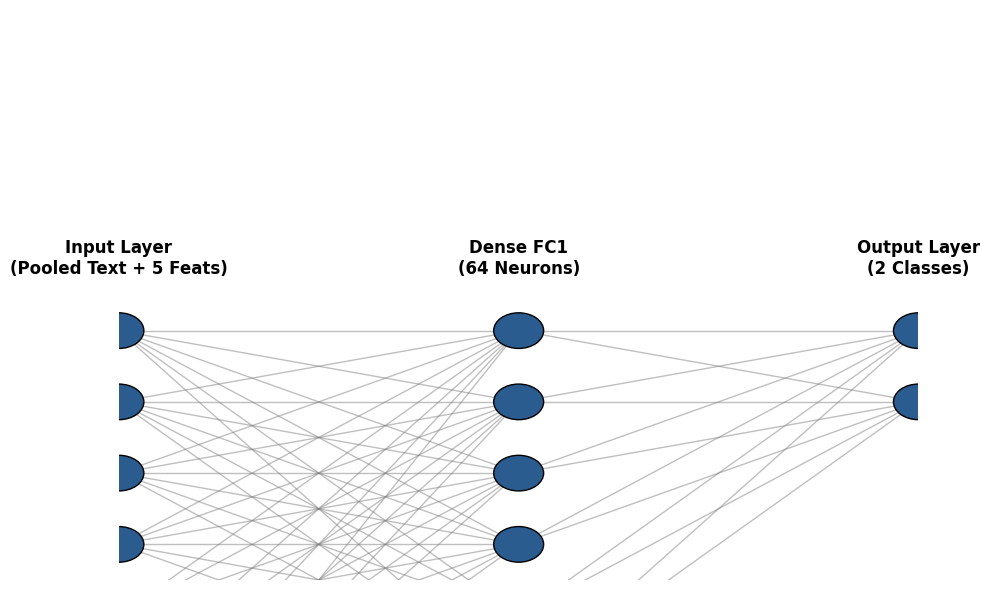

In [5]:
import matplotlib.pyplot as plt

def draw_neural_network(layer_sizes, filename="nn_connection_graph.png"):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    v_spacing = 1.0 / max(layer_sizes)
    h_spacing = 1.0 / (len(layer_sizes) - 1)

    layer_top_0 = v_spacing * (max(layer_sizes) - 1) / 2.0

    # Draw nodes
    nodes = []
    for i, n_nodes in enumerate(layer_sizes):
        layer_top = v_spacing * (n_nodes - 1) / 2.0
        layer_nodes = []
        for j in range(n_nodes):
            x = i * h_spacing
            y = layer_top_0 - j * v_spacing
            layer_nodes.append((x, y))
            circle = plt.Circle((x, y), v_spacing / 4, color='#2b5c8f', ec='k', zorder=4)
            ax.add_patch(circle)
        nodes.append(layer_nodes)

    # Draw connection lines
    for i in range(len(layer_sizes) - 1):
        for n1 in nodes[i]:
            for n2 in nodes[i + 1]:
                line = plt.Line2D([n1[0], n2[0]], [n1[1], n2[1]], color='gray', alpha=0.5, lw=1)
                ax.add_line(line)

    # Layer Labels
    labels = ['Input Layer\n(Pooled Text + 5 Feats)', 'Dense FC1\n(64 Neurons)', 'Output Layer\n(2 Classes)']
    for i, label in enumerate(labels):
        ax.text(i * h_spacing, layer_top_0 + 0.1, label, horizontalalignment='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Sample visualization of network layers (e.g., compressed representation of layer sizes)
draw_neural_network([8, 6, 2], filename="MultiInputNN_Connections.png")

In [8]:
import torch
import torch.nn as nn
from torchview import draw_graph

# =========================================================
# NEURAL NETWORK DEFINITIONS
# =========================================================

class TextOnlyNN(nn.Module):
    def __init__(self, vocab_size=5000, embedding_dim=100):
        super(TextOnlyNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc1 = nn.Linear(embedding_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        embedded = self.embedding(x)
        pooled = torch.mean(embedded, dim=1)
        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.fc2(out)
        return out


class MultiInputNN(nn.Module):
    def __init__(self, vocab_size=5000, embedding_dim=100):
        super(MultiInputNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc1 = nn.Linear(embedding_dim + 5, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x_text, x_feats):
        embedded = self.embedding(x_text)
        pooled = torch.mean(embedded, dim=1)
        concatenated = torch.cat((pooled, x_feats), dim=1)
        out = self.fc1(concatenated)
        out = self.relu(out)
        out = self.fc2(out)
        return out


# =========================================================
# GENERATE DIAGRAM IMAGES
# =========================================================

# 1. Visualize TextOnlyNN
model_text = TextOnlyNN(vocab_size=5000, embedding_dim=100)
dummy_text_input = torch.zeros((64, 100), dtype=torch.long)

graph_text = draw_graph(
    model_text,
    input_data=dummy_text_input,
    graph_name="TextOnlyNN_Architecture",
    expand_nested=True,
    save_graph=True,
    filename="TextOnlyNN_diagram"
)

# 2. Visualize MultiInputNN (Text + Engineered Features)
model_multi = MultiInputNN(vocab_size=5000, embedding_dim=100)
dummy_feats_input = torch.zeros((64, 5), dtype=torch.float32)

graph_multi = draw_graph(
    model_multi,
    input_data=(dummy_text_input, dummy_feats_input),
    graph_name="MultiInputNN_Architecture",
    expand_nested=True,
    save_graph=True,
    filename="MultiInputNN_diagram1"
)

print("Architecture diagrams saved as PNG images!")

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH